# Data Processing Exploratory Data Analysis

## Setup

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import pathlib as Path

In [2]:
import stanza
nlp = stanza.Pipeline('en')
print("Stanza ready!")

2025-10-24 09:51:27 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2025-10-24 09:51:27 INFO: Downloaded file to /Users/annaglass/stanza_resources/resources.json
2025-10-24 09:51:29 INFO: Loading these models for language: en (English):
| Processor    | Package                   |
--------------------------------------------
| tokenize     | combined                  |
| mwt          | combined                  |
| pos          | combined_charlm           |
| lemma        | combined_nocharlm         |
| constituency | ptb3-revised_charlm       |
| depparse     | combined_charlm           |
| sentiment    | sstplus_charlm            |
| ner          | ontonotes-ww-multi_charlm |

2025-10-24 09:51:29 INFO: Using device: cpu
2025-10-24 09:51:29 INFO: Loading: tokenize
2025-10-24 09:51:30 INFO: Loading: mwt
2025-10-24 09:51:30 INFO: Loading: pos
2025-10-24 09:51:31 INFO: Loading: lemma
2025-10-24 09:51:31 INFO: Loading: constituency
2025-10-24 09:51:31 INFO: Loading: depparse
2025-10-24 09:51:32 INFO: Loading: sentiment
2025-10-24 09:51:32 INFO: Loading: n

Stanza ready!


## Raw Data Exploration

In [3]:
import os
print(os.getcwd())

/Users/annaglass/capstone/capstone/analysis


In [4]:
# Choosing one file for example for processing decisions
rawDF = pd.read_excel("../data_storage/raw_data/penta_raw_1.xlsx", engine="openpyxl")

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [5]:
rawDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499999 entries, 0 to 499998
Data columns (total 31 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   tag_name            499999 non-null  object        
 1   article_id          499999 non-null  int64         
 2   source_feed_name    499999 non-null  object        
 3   load_date           499999 non-null  datetime64[ns]
 4   load_datetime       499999 non-null  datetime64[ns]
 5   feed_name           499999 non-null  object        
 6   headline            499992 non-null  object        
 7   article_body        499999 non-null  object        
 8   author_name         499109 non-null  object        
 9   source_unique_id    499942 non-null  object        
 10  source_type_name    499999 non-null  object        
 11  channel_name        499999 non-null  object        
 12  genre               58044 non-null   object        
 13  publisher_name      496870 no

In [6]:
rawDF.head()

,tag_name,article_id,source_feed_name,load_date,load_datetime,feed_name,headline,article_body,author_name,source_unique_id,...,iso_language_code,circulation_size,page,sentiment_score,source_type,engagement,sentiment_band,hit_strength,vipr_weight,vipr_score
0,Public Health,17813004513,regionals-web,2024-01-01,2024-01-01 00:00:07.895,opoint,Inside the family-run dairy farm at centre of ...,"Mrs Kirkham's Lancashire Cheese, which is loc...","Rory Tingle, Emily Stearn",4394-12152242,...,en,156069,NaN,-18,Regional News,0,Negative,1,350,-6300
1,Health Campaign,17813005960,consumer,2024-01-01,2024-01-01 00:00:17.311,opoint,Saiba como agir em casos de queimadura por fog...,A virada de Ano Novo é comumente marcada pe...,uncredited,259876-24234,...,pt,47524,NaN,-31,Consumer,0,Negative,1,105,-3255
2,Health Campaign,17813007006,regionals-web,2024-01-01,2024-01-01 00:00:12.570,opoint,列宁的6个墨水瓶：贫穷限制了你的想象力，也限制了你的购买力,1980年代我读小学，有篇课文讲的是列宁。列宁想在狱中写书，但监狱里只能看书不允许写字，既...,uncredited,43329-9359961,...,zh,43879575,NaN,-16,Regional News,0,Negative,1,400,-6400
3,Public Health,17813007724,broadcast-radio,2024-01-01,2024-01-01 00:00:43.095,tveyes,4BC 1116 News Talk: A bit of rat boys and they...,"A bit of rat boys and they mix it up, stick a...",uncredited,f845c9c8-0908-4d2c-98d2-e84596f8f390,...,en,1019,NaN,-18,Radio,0,Negative,1,312,-5616
4,Public Health,17813008458,broadcast-radio,2024-01-01,2024-01-01 00:00:06.199,tveyes,ABC South East SA: I'd be doing. But if you wo...,I'd be doing. But if you would have asked me ...,uncredited,c236e220-ce6f-450d-b97f-b862631e7512,...,en,1154,NaN,22,Radio,0,Positive,2,262,5764


In [7]:
# Check for Missing Values
rawDF.isna().sum()

tag_name                   0
article_id                 0
source_feed_name           0
load_date                  0
load_datetime              0
feed_name                  0
headline                   7
article_body               0
author_name              890
source_unique_id          57
source_type_name           0
channel_name               0
genre                 441955
publisher_name          3129
publication_name           0
publisher_site_url      2099
published_datetime         0
article_url                0
region                 46709
subregion             172508
country                    0
iso_language_code         10
circulation_size           0
page                  498470
sentiment_score            0
source_type                0
engagement                 0
sentiment_band             0
hit_strength               0
vipr_weight                0
vipr_score                 0
dtype: int64

In [8]:
# Dropped Column Analysis
DROP_COLS = ["publisher_site_url"
             ,"page"              # Not needed
             ,"article_url"       # Not needed 
             ,"source_unique_id"  # Not needed
             ,"source_type_name"  # Duplicate column with source_type
             ,"region"            # Very messy data after filtering to US, does not provide value. 
             ,"load_datetime"     # Not needed 
             ,"engagement"        # Not a used column by Penta  
             ,"genre"             # Not a used column by Penta  
             ,"iso_language_code" # Not needed as all items are in English after filtering 
             ,"load_date"         # Want to use the published_date" 
             ]
rawDF[DROP_COLS].head()

,publisher_site_url,page,article_url,source_unique_id,source_type_name,region,load_datetime,engagement,genre,iso_language_code,load_date
0,https://www.einnews.com,NaN,https://foodsafety.einnews.com/article/678033599,4394-12152242,Regional News,North America,2024-01-01 00:00:07.895,0,NaN,en,2024-01-01
1,https://www.gruporioclarosp.com.br,NaN,https://www.gruporioclarosp.com.br/2023/12/31/...,259876-24234,Consumer,Latin America,2024-01-01 00:00:17.311,0,NaN,pt,2024-01-01
2,http://www.163.com,NaN,https://m.163.com/news/article/INAC5CEN05563SW...,43329-9359961,Regional News,Asia,2024-01-01 00:00:12.570,0,NaN,zh,2024-01-01
3,Broadcast,NaN,https://penta.live/getBroadcastArticleLink?art...,f845c9c8-0908-4d2c-98d2-e84596f8f390,Radio,NaN,2024-01-01 00:00:43.095,0,AURAD4BC,en,2024-01-01
4,Broadcast,NaN,https://penta.live/getBroadcastArticleLink?art...,c236e220-ce6f-450d-b97f-b862631e7512,Radio,NaN,2024-01-01 00:00:06.199,0,AURADABCSOUTHEASTSA,en,2024-01-01


In [9]:
NUMERIC_REQUIRED = ["vipr_weight", "circulation", "sentiment"] 

def apply_filters(df: pd.DataFrame) -> pd.DataFrame:
    print(f"start:            {df.shape[0]:,} rows × {df.shape[1]} cols")

    # 1) drop NA in required numeric columns (only those that exist)
    req = [c for c in NUMERIC_REQUIRED if c in df.columns]
    if req:
        df = df.dropna(subset=req)
    print(f"after dropna:     {df.shape[0]:,} rows × {df.shape[1]} cols (req={req})")

    # 2) filter to US
    if "country" in df.columns:
        df = df[df["country"] == "United States"]
    print(f"after US filter:  {df.shape[0]:,} rows × {df.shape[1]} cols")

    # 3) drop metadata columns (only those that exist)
    drops = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=drops, errors="ignore")
    print(f"after drop cols:  {df.shape[0]:,} rows × {df.shape[1]} cols (dropped {len(drops)})")

    return df.head(5)

apply_filters(rawDF)

start:            499,999 rows × 31 cols
after dropna:     499,999 rows × 31 cols (req=['vipr_weight'])
after US filter:  117,388 rows × 31 cols
after drop cols:  117,388 rows × 20 cols (dropped 11)


,tag_name,article_id,source_feed_name,feed_name,headline,article_body,author_name,channel_name,publisher_name,publication_name,published_datetime,subregion,country,circulation_size,sentiment_score,source_type,sentiment_band,hit_strength,vipr_weight,vipr_score
0,Public Health,17813004513,regionals-web,opoint,Inside the family-run dairy farm at centre of ...,"Mrs Kirkham's Lancashire Cheese, which is loc...","Rory Tingle, Emily Stearn",Web,Ein News,Ein News,2023-12-29 17:18:24.000,NaN,United States,156069,-18,Regional News,Negative,1,350,-6300
15,Public Health,17813026449,wires,opoint,German cardinal says Pope Francis’ same-sex bl...,A German cardinal in the Catholic Church rema...,uncredited,Web,Lucianne,Lucianne,2024-01-01 00:06:15.000,NaN,United States,59374,-27,Wires,Negative,1,25,-675
23,Public Health,17813035135,consumer,opoint,'23 SAW SIGNIFICANT POSITIVE DEVELOPMENTS IN S...,"TUESDAY, DECEMBER 26, 2023 2023 was a toug...",Al Cross,Web,The Levisa Lazer,The Levisa Lazer,2024-01-01 00:08:07.000,NaN,United States,845,-21,Consumer,Negative,2,500,-10500
30,Public Health,17813043680,broadcast-tv,tveyes,NHL Hockey,Boston Bruins at Detroit Red Wings. From Littl...,uncredited,Broadcast,Bally Sports Detroit,Bally Sports Detroit,2023-12-31 23:59:33.615,NaN,United States,818,8,TV,Neutral,1,271,2168
37,Public Health,17813051573,regionals-web,opoint,Death rates from rare heart diseases rise amon...,Researchers warn that the opioid epidemic i...,Remon Buul,Web,News Net Daily,News Net Daily,2023-12-31 18:00:46.000,NaN,United States,9403,-43,Regional News,Negative,4,1122,-48246


The majority of data processing decisions are made with computer resources at top of mind, specifically concerning the filtering, besides dropping missing values. Knowing GitHubs size limit of files of 10MB to be pushed, and Streamlit's ability to only work with 1 GB of data, filtering decisions for country, region, and language had to be made. In an ideal world, these columns could be used to further cluster and analyze the data. The only other data processing done was appending this with the other 9 raw data files, as well as processing the text data to start with a clean base. One item that was noticied was inconsistencies in the naming convention for "Unknown" or "Other" items in categorical columns. This was addressed in data processing. 

## Processed Data

In [10]:
import os
os.getcwd()

'/Users/annaglass/capstone/capstone/analysis'

In [11]:
cleanDF = pd.read_parquet("../data_storage/processed_data/processed_data.parquet")

In [12]:
cleanDF.head()

,article_body,article_id,author_name,circulation_size,feed_name,headline,hit_strength,publication_name,published_datetime,publisher_name,sentiment_band,sentiment_score,source_feed_name,source_type,tag_name,vipr_score,vipr_weight,headline_token_count,body_token_count,token_count
0,mr kirkham lancashire cheese located picturesq...,17813004513,rory_tingle_emily_stearn,156069,opoint,inside family run dairy farm centre coli outbr...,1,ein_news,2023-12-29 17:18:24,ein_news,negative,-18,regionals_web,regional_news,public_health,-6300,350,20,662,682
1,german cardinal catholic church remarked pope ...,17813026449,unknown,59374,opoint,german cardinal say pope francis sex blessing ...,1,lucianne,2024-01-01 00:06:15,lucianne,negative,-27,wires,wires,public_health,-675,25,10,700,710
2,tuesday december tough year many way saw signi...,17813035135,al_cross,845,opoint,saw significant positive development science m...,2,the_levisa_lazer,2024-01-01 00:08:07,the_levisa_lazer,negative,-21,consumer,consumer,public_health,-10500,500,6,286,292
3,boston bruin detroit red wing little caesar ar...,17813043680,unknown,818,tveyes,nhl hockey,1,bally_sports_detroit,2023-12-31 23:59:33.615000,bally_sports_detroit,neutral,8,broadcast_tv,tv,public_health,2168,271,2,379,381
4,researcher warn opioid epidemic fueling deadly...,17813051573,remon_buul,9403,opoint,death rate rare heart disease rise among young...,4,news_net_daily,2023-12-31 18:00:46,news_net_daily,negative,-43,regionals_web,regional_news,public_health,-48246,1122,9,677,686


In [13]:
cleanDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899519 entries, 0 to 899518
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype                 
---  ------                --------------   -----                 
 0   article_body          899519 non-null  string                
 1   article_id            899519 non-null  Int64                 
 2   author_name           899519 non-null  string                
 3   circulation_size      899519 non-null  Int64                 
 4   feed_name             899519 non-null  string                
 5   headline              899519 non-null  string                
 6   hit_strength          899519 non-null  Int64                 
 7   publication_name      899519 non-null  string                
 8   published_datetime    899518 non-null  timestamp[ns][pyarrow]
 9   publisher_name        899519 non-null  string                
 10  sentiment_band        899519 non-null  string                
 11  sentiment_sco

In [14]:
cleanDF.isna().sum()

article_body            0
article_id              0
author_name             0
circulation_size        0
feed_name               0
headline                0
hit_strength            0
publication_name        0
published_datetime      1
publisher_name          0
sentiment_band          0
sentiment_score         0
source_feed_name        0
source_type             0
tag_name                0
vipr_score              0
vipr_weight             0
headline_token_count    0
body_token_count        0
token_count             0
dtype: int64

In [16]:
from pathlib import Path

path = Path("data_storage/processed_data/processed_data.parquet")

print(f"Observations: {cleanDF.shape[0]:,} rows × {cleanDF.shape[1]} columns")
print(f"In-memory size: {cleanDF.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

Observations: 899,519 rows × 20 columns
In-memory size: 3392.78 MB


The dataset has gone through text processing, filtering, and is in great shape for modeling now. However, looking at the size of the dataset, it is far too large to be used for modeling under the computational constraints of the capstone project. This leads us to sampling the data. 

## Sampled Dataset

The sampling technique used was originally SFFS to protect the network of individuals, however after talking with Penta, priorities moved away from the network analysis. We decided to use stratified sampling because it has a similar logic concept to SFFS, however, it is much more computationally effective, as SFFS took 12+ hours to run. 

In [17]:
sampleDF = pd.read_parquet("../data_storage/processed_data/sampled_data.parquet")

In [18]:
sampleDF.head()

,article_body,article_id,author_name,circulation_size,feed_name,headline,hit_strength,publication_name,published_datetime,publisher_name,sentiment_band,sentiment_score,source_feed_name,source_type,tag_name,vipr_score,vipr_weight,headline_token_count,body_token_count,token_count
0,johannesburg south africa los angeles calif ja...,17875604184,unknown,800,opoint,scientology africa five year unconditional hel...,3,daily_journal,2024-01-20 11:54:19,daily_journal,positive,26,regionals_web,regional_news,public_health,23400,900,13,510,523
1,news provided ein presswire apr london united ...,18122540973,unknown,1066890,opoint,health political choice advancing indigenous p...,7,wkrn,2024-04-07 14:13:13,wkrn,positive,34,regionals_web,regional_news,public_health,44608,1312,10,357,367
2,honor earth day chamber county community healt...,18172305397,charlotte_reames,14529,opoint,wellness center launch garden micro pantry ear...,2,valley_times_news,2024-04-23 14:16:06,valley_times_news,positive,20,regionals_web,regional_news,public_health,20220,1011,8,202,210
3,lima wlio flu season reach peak hospital publi...,19107290711,todd_cummins,37122,opoint,flu case surge allen county health official ur...,6,hometown_lima_stations,2025-02-13 00:15:22,hometown_lima_stations,neutral,-3,regionals_web,regional_news,public_health,-4998,1666,13,156,169
4,cnn number measles case around world nearly do...,18186873367,katherine_dillinger,1038,opoint,global measles case nearly doubled one year re...,2,cnn_edition,2024-04-27 22:09:46,cnn_edition,neutral,0,web,general_news,public_health,0,1083,9,290,299


In [19]:
sampleDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype                 
---  ------                --------------   -----                 
 0   article_body          100000 non-null  string                
 1   article_id            100000 non-null  Int64                 
 2   author_name           100000 non-null  string                
 3   circulation_size      100000 non-null  Int64                 
 4   feed_name             100000 non-null  string                
 5   headline              100000 non-null  string                
 6   hit_strength          100000 non-null  Int64                 
 7   publication_name      100000 non-null  string                
 8   published_datetime    100000 non-null  timestamp[ns][pyarrow]
 9   publisher_name        100000 non-null  string                
 10  sentiment_band        100000 non-null  string                
 11  sentiment_scor

In [20]:
sampleDF.isna().sum()

article_body            0
article_id              0
author_name             0
circulation_size        0
feed_name               0
headline                0
hit_strength            0
publication_name        0
published_datetime      0
publisher_name          0
sentiment_band          0
sentiment_score         0
source_feed_name        0
source_type             0
tag_name                0
vipr_score              0
vipr_weight             0
headline_token_count    0
body_token_count        0
token_count             0
dtype: int64

In [ ]:
# Check Size of Dataset
path = Path("data_storage/processed_data/sampled_data.parquet")

print(f"Observations: {cleanDF.shape[0]:,} rows × {cleanDF.shape[1]} columns")
print(f"In-memory size: {cleanDF.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

Observations: 100,000 rows × 18 columns
In-memory size: 372.29 MB


Now that the data has been sampled down a great amount, there will be fewer issues in modeling and future efforts. One key takeaway here is that we will have to split the dataset into 4 parts to push to Github, and ultimately be pushed to Streamlit. 

## Trends & Analysis

As the sampled dataset is what we are going to be using for modeling, a detailed exploratory analysis is performed below.

In [42]:
print("\nBasic Statistics (Numeric Columns):")
print(sampleDF.describe())


Basic Statistics (Numeric Columns):
       circulation_size  hit_strength  sentiment_score    vipr_score  \
count          100000.0      100000.0         100000.0      100000.0   
mean      2264837.42243       3.36156         -7.87898   -6716.08988   
std     20547342.341867      3.637258        25.910839  26200.896041   
min                 1.0           0.0           -100.0    -1080000.0   
25%              1045.0           1.0            -25.0      -13570.0   
50%              6932.0           2.0             -6.0       -2120.0   
75%            156578.5           4.0              8.0        2901.0   
max         428640966.0         170.0            100.0      277400.0   

       vipr_weight  headline_token_count  body_token_count  token_count  
count     100000.0              100000.0          100000.0     100000.0  
mean     705.60101               8.55704         425.88932    434.44636  
std     664.488778              9.438639        352.292592   352.934986  
min           25.0

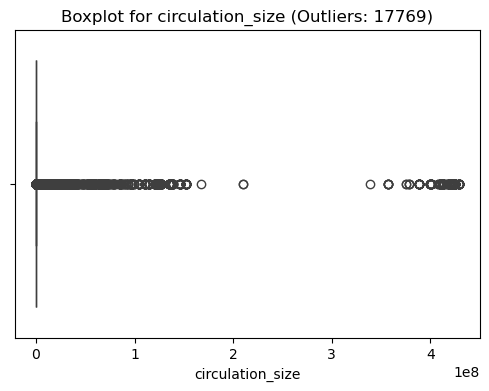

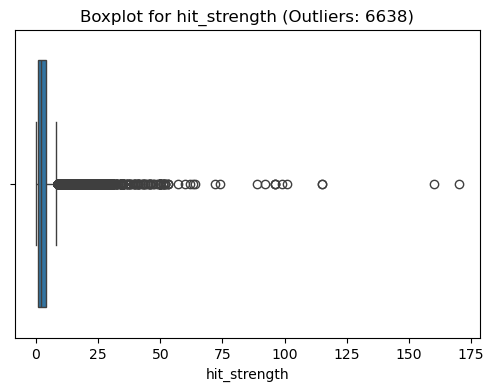

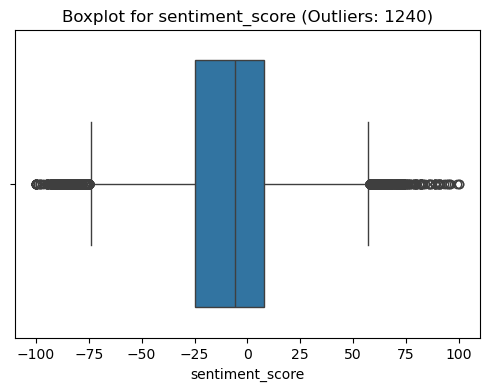

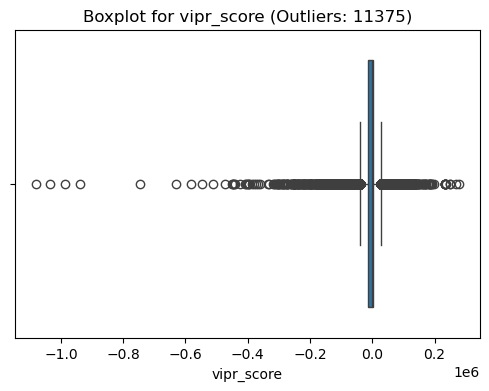

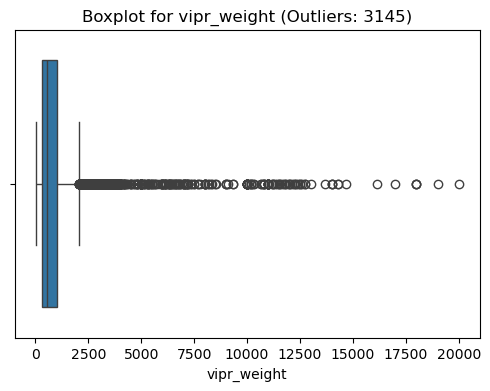

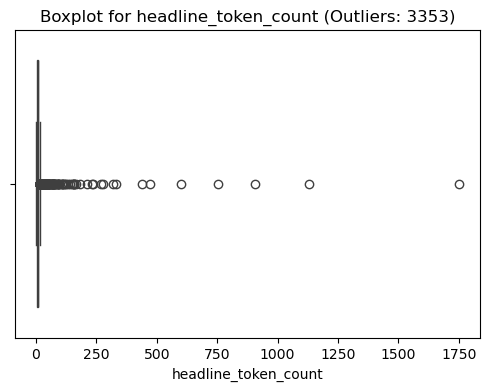

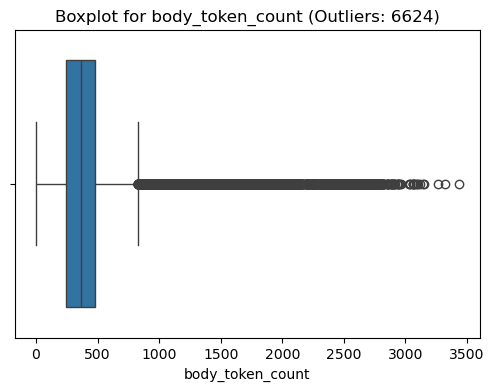

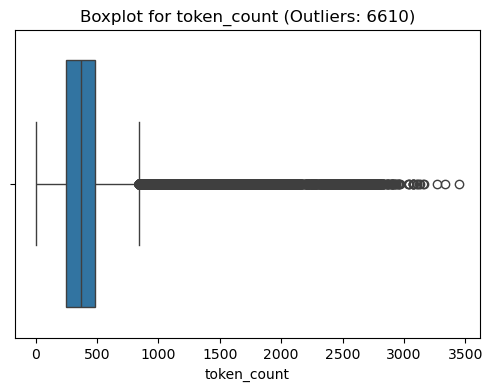

Outlier counts by column:
{'circulation_size': 17769, 'hit_strength': 6638, 'sentiment_score': 1240, 'vipr_score': 11375, 'vipr_weight': 3145, 'headline_token_count': 3353, 'body_token_count': 6624, 'token_count': 6610}


,article_body,author_name,circulation_size,feed_name,headline,hit_strength,publication_name,publisher_name,sentiment_band,sentiment_score,source_feed_name,source_type,tag_name,vipr_score,vipr_weight,headline_token_count,body_token_count,token_count
0,johannesburg south africa los angeles calif ja...,unknown,800,opoint,scientology africa five year unconditional hel...,3,daily_journal,daily_journal,positive,26,regionals_web,regional_news,public_health,23400,900,13,510,523
1,news provided ein presswire apr london united ...,unknown,1066890,opoint,health political choice advancing indigenous p...,7,wkrn,wkrn,positive,34,regionals_web,regional_news,public_health,44608,1312,10,357,367
2,honor earth day chamber county community healt...,charlotte_reames,14529,opoint,wellness center launch garden micro pantry ear...,2,valley_times_news,valley_times_news,positive,20,regionals_web,regional_news,public_health,20220,1011,8,202,210
3,lima wlio flu season reach peak hospital publi...,todd_cummins,37122,opoint,flu case surge allen county health official ur...,6,hometown_lima_stations,hometown_lima_stations,neutral,-3,regionals_web,regional_news,public_health,-4998,1666,13,156,169
4,cnn number measles case around world nearly do...,katherine_dillinger,1038,opoint,global measles case nearly doubled one year re...,2,cnn_edition,cnn_edition,neutral,0,web,general_news,public_health,0,1083,9,290,299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,uganda launch malaria vaccination million chil...,unknown,64723,opoint,uganda launch malaria vaccination million child,2,mangaloreancom,mangaloreancom,positive,20,regionals_web,regional_news,public_health,15320,766,6,286,292
99996,rzburg germany cambridge mass jan globe newswi...,unknown,855,opoint,fighting leprosy artificial intelligence dahw ...,2,connect_iredell,connect_iredell,neutral,-5,consumer,consumer,public_health,-875,175,20,719,739
99997,news press release humanitarian situation civi...,unknown,1151885,opoint,sudan deteriorating situation fasher health sy...,1,reliefweb,reliefweb,negative,-46,web,general_news,public_health,-11500,250,8,326,334
99998,originally published minute medicine view orig...,thomas_su,194982,opoint,individualized acupuncture associated signific...,1,accessmedicine,accessmedicine,negative,-64,consumer,consumer,world_health_leadership,-17344,271,8,419,427


In [46]:
def detect_outliers_iqr(df, cols, remove=False):
    outlier_indices = {}
    df_clean = sampleDF.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices[col] = len(outliers)
        
    
        if remove:
            df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        
        
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot for {col} (Outliers: {len(outliers)})")
        plt.show()
    
    print("Outlier counts by column:")
    print(outlier_indices)
    
    return df_clean

numeric_cols = sampleDF.select_dtypes(include=[np.number]).columns.tolist()
detect_outliers_iqr(sampleDF, numeric_cols, remove = False)

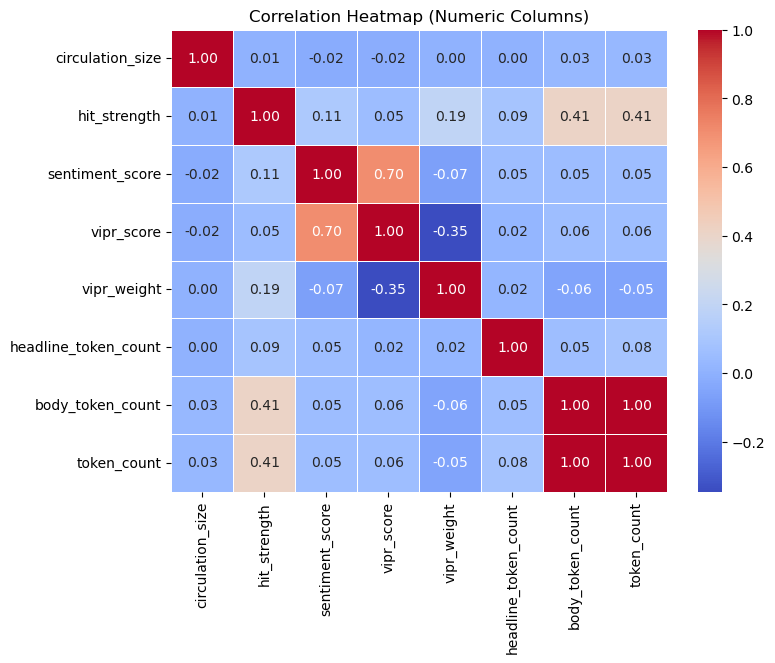

In [49]:
corr_matrix = sampleDF[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

Results show signs of multicolinearity with token count columns, however, they are more used for general reference to see the length of the article -- therefore is not a worry. 

In [52]:
sampleDF.columns

Index(['article_body', 'author_name', 'circulation_size', 'feed_name',
       'headline', 'hit_strength', 'publication_name', 'publisher_name',
       'sentiment_band', 'sentiment_score', 'source_feed_name', 'source_type',
       'tag_name', 'vipr_score', 'vipr_weight', 'headline_token_count',
       'body_token_count', 'token_count'],
      dtype='object')

In [ ]:
def eda_tables_dual(df: pd.DataFrame):
    """
    Build EDA tables for:
      - Top publications (article_count, avg_circulation)
      - Avg circulation by source type
      - EDA by channel (article_count, avg_circulation)
      - Daily article & circulation distribution
      - Monthly article & circulation distribution
      - Sentiment band EDA (distribution)
      - Sentiment score EDA (summary + by band)

    Returns:
      {
        "full": { <tables> },
        "conversion": { <tables> }  # only if 'conversion_proxy' in df
      }
    """

    def _build(sub_df: pd.DataFrame):
        out = {}

        # ---- time keys
        day = sub_df["load_date"].dt.date
        month = sub_df["load_date"].dt.to_period("M").dt.to_timestamp()

        # ---- 1) Top publications
        out["top_publications"] = (
            sub_df.groupby("publication_name", dropna=False)
                  .agg(article_count=("article_id", "count"),
                       avg_circulation=("circulation_size", "mean"))
                  .sort_values(["article_count","avg_circulation"], ascending=[False, False])
                  .head(25)
                  .reset_index()
        )

        # ---- 2) Avg circulation by source type
        st_col = "source_type_name" if "source_type_name" in sub_df.columns else "source_type"
        out["avg_circulation_by_source_type"] = (
            sub_df.groupby(st_col, dropna=False)
                  .agg(avg_circulation=("circulation_size","mean"),
                       median_circulation=("circulation_size","median"),
                       article_count=("article_id","count"))
                  .sort_values("avg_circulation", ascending=False)
                  .reset_index()
        )

        # ---- 3) EDA by channel (count + avg circ)
        out["by_channel"] = (
            sub_df.groupby("channel_name", dropna=False)
                  .agg(article_count=("article_id","count"),
                       avg_circulation=("circulation_size","mean"))
                  .sort_values(["article_count","avg_circulation"], ascending=[False, False])
                  .reset_index()
        )

        # ---- 4) Daily distribution (articles + total circulation)
        out["daily_distribution"] = (
            sub_df.assign(DAY=day)
                  .groupby("DAY", as_index=False)
                  .agg(article_count=("article_id","count"),
                       circulation_total=("circulation_size","sum"))
                  .sort_values("DAY")
        )

        # ---- 5) Monthly distribution (articles + total circulation)
        out["monthly_distribution"] = (
            sub_df.assign(MONTH=month)
                  .groupby("MONTH", as_index=False)
                  .agg(article_count=("article_id","count"),
                       circulation_total=("circulation_size","sum"))
                  .sort_values("MONTH")
        )

        # ---- 6) Sentiment band EDA
        out["sentiment_band_distribution"] = (
            sub_df["sentiment_band"].value_counts(dropna=False)
                .rename_axis("sentiment_band")
                .reset_index(name="count")
        )
        # with percentages
        total_rows = len(sub_df)
        if total_rows > 0:
            out["sentiment_band_distribution"]["pct"] = (
                out["sentiment_band_distribution"]["count"] / total_rows * 100
            ).round(2)

        # ---- 7) Sentiment score EDA
        # overall summary
        if "sentiment_score" in sub_df.columns:
            out["sentiment_score_summary"] = (
                sub_df["sentiment_score"].describe().to_frame("value")
            )
            # by band
            out["sentiment_score_by_band"] = (
                sub_df.groupby("sentiment_band", dropna=False)["sentiment_score"]
                      .agg(mean="mean", median="median", std="std", count="count")
                      .reset_index()
                      .sort_values("mean", ascending=False)
            )
        else:
            out["sentiment_score_summary"] = pd.DataFrame()
            out["sentiment_score_by_band"] = pd.DataFrame()

        return out

    results = {"full": _build(df)}

    # add conversion subset if available
    if "conversion_proxy" in df.columns:
        results["conversion"] = _build(df[df["conversion_proxy"] == 1].copy())

    return results

eda_tables_dual(sampleDF)["full"]

KeyError: 'load_date'

In [ ]:
tables_dual = eda_tables_dual(sampledDF)
tables_dual["full"]["by_channel"].head()

In [ ]:
def eda_visuals_matplotlib(df: pd.DataFrame, title_prefix="Dataset"):
    # ---- 0) small helpers  ----
    def barh_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(10, 6))
        s = s.sort_values(ascending=True)
        plt.barh(s.index.astype(str), s.values, color="skyblue")
        plt.title(f"{title_prefix}: {title}", fontsize=14)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(axis="x", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()

    def barh_from_df(df_in: pd.DataFrame, cat_col: str, val_col: str, title: str, xlabel: str, ylabel: str, top_n=15):
        if df_in.empty or cat_col not in df_in or val_col not in df_in: return
        dd = df_in[[cat_col, val_col]].dropna()
        dd = dd.groupby(cat_col)[val_col].mean().sort_values(ascending=False).head(top_n)
        barh_from_series(dd, title, xlabel, ylabel)

    def line_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(12, 5))
        plt.plot(s.index, s.values, marker="o", label=ylabel)
        plt.title(f"{title_prefix}: {title}", fontsize=14)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    def bar_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(12, 5))
        plt.bar(s.index.astype(str), s.values, color="orange")
        plt.title(f"{title_prefix}: {title}", fontsize=14)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    def hist1(col: str, bins=40, logscale=False, title_suffix=""):
        if col not in df: return
        x = pd.to_numeric(df[col], errors="coerce").dropna()
        if x.empty: return
        plt.figure(figsize=(8, 5))
        plt.hist(x.values, bins=bins, color="green", alpha=0.7)
        if logscale:
            plt.yscale("log")
        ttl = f"{title_prefix}: Distribution of {col}"
        if title_suffix: ttl += f" ({title_suffix})"
        plt.title(ttl, fontsize=14)
        plt.xlabel(f"{col} Value", fontsize=12)
        plt.ylabel("Frequency (Count)", fontsize=12)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    # ---- 1) Top publications by article count ----
    if "publication_name" in df and "article_id" in df:
        top_pubs = df["publication_name"].value_counts().head(15)
        barh_from_series(top_pubs, "Top Publications by Article Count", "Article Count", "Publication Name")

    # ---- 2) Average circulation by source type ----
    st_col = "source_type_name" if "source_type_name" in df.columns else ("source_type" if "source_type" in df.columns else None)
    if st_col and "circulation_size" in df:
        barh_from_df(df, st_col, "circulation_size", "Average Circulation by Source Type", "Average Circulation (Units)", "Source Type", top_n=20)

    # ---- 3) EDA by channel (article count) ----
    if "channel_name" in df:
        top_channels = df["channel_name"].value_counts().head(15)
        barh_from_series(top_channels, "Top Channels by Article Count", "Article Count", "Channel Name")

    # ---- 4) Daily article distribution (count) ----
    if "load_date" in df and "article_id" in df:
        ld = pd.to_datetime(df["load_date"], errors="coerce")
        daily_counts = df.assign(_day=ld.dt.date).groupby("_day")["article_id"].count()
        line_from_series(daily_counts, "Daily Article Count Over Time", "Date", "Number of Articles")

    # ---- 5) Monthly article distribution (count) ----
    if "load_date" in df and "article_id" in df:
        month = pd.to_datetime(df["load_date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
        monthly_counts = df.assign(_month=month).groupby("_month")["article_id"].count()
        bar_from_series(monthly_counts, "Monthly Article Count", "Month", "Number of Articles")

    # ---- 6) Daily circulation sum ----
    if "load_date" in df and "circulation_size" in df:
        ld = pd.to_datetime(df["load_date"], errors="coerce")
        daily_circ = df.assign(_day=ld.dt.date).groupby("_day")["circulation_size"].sum()
        line_from_series(daily_circ, "Daily Circulation Volume Over Time", "Date", "Total Circulation Volume")

    # ---- 7) Monthly circulation sum ----
    if "load_date" in df and "circulation_size" in df:
        month = pd.to_datetime(df["load_date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
        monthly_circ = df.assign(_month=month).groupby("_month")["circulation_size"].sum()
        bar_from_series(monthly_circ, "Monthly Circulation Volume", "Month", "Total Circulation Volume")

    # ---- 8) Sentiment band distribution ----
    if "sentiment_band" in df:
        band_counts = df["sentiment_band"].value_counts()
        bar_from_series(band_counts, "Sentiment Band Distribution", "Sentiment Band", "Count of Articles")

    # ---- 9) Sentiment score distribution ----
    if "sentiment_score" in df:
        hist1("sentiment_score", bins=50, title_suffix="linear scale")

    for col in ["vipr_weight_log", "hit_strength_log", "circulation_size_log"]:
        if col in df.columns:
            hist1(col, bins=50, title_suffix="log-transformed")

    # Clipped vipr score
    if "vipr_score_clip" in df.columns:
        hist1("vipr_score_clip", bins=60, title_suffix="clipped (1st–99th pct)")

    # Optional: relationship between sentiment_score and vipr_score_clip
    if "vipr_score_clip" in df.columns and "sentiment_score" in df.columns:
        x = pd.to_numeric(df["vipr_score_clip"], errors="coerce")
        y = pd.to_numeric(df["sentiment_score"], errors="coerce")
        m = (~x.isna()) & (~y.isna())
        if m.any():
            plt.figure(figsize=(8, 6))
            plt.scatter(x[m].values, y[m].values, alpha=0.15, s=8, c="purple", label="Articles")
            plt.title(f"{title_prefix}: VIPR Score (clipped) vs Sentiment Score", fontsize=14)
            plt.xlabel("VIPR Score (Clipped)", fontsize=12)
            plt.ylabel("Sentiment Score", fontsize=12)
            plt.legend()
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.tight_layout()
            plt.show()

eda_visuals_matplotlib(sampleDF, title_prefix="Conversion Proxy Dataset")